In [32]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import warnings

warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
file_path = '/content/drive/MyDrive/DAWP final/train_master.parquet'
df = pd.read_parquet(file_path)



In [34]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.day_name()

In [35]:
sns.set(style="whitegrid")
colors = sns.color_palette("viridis")



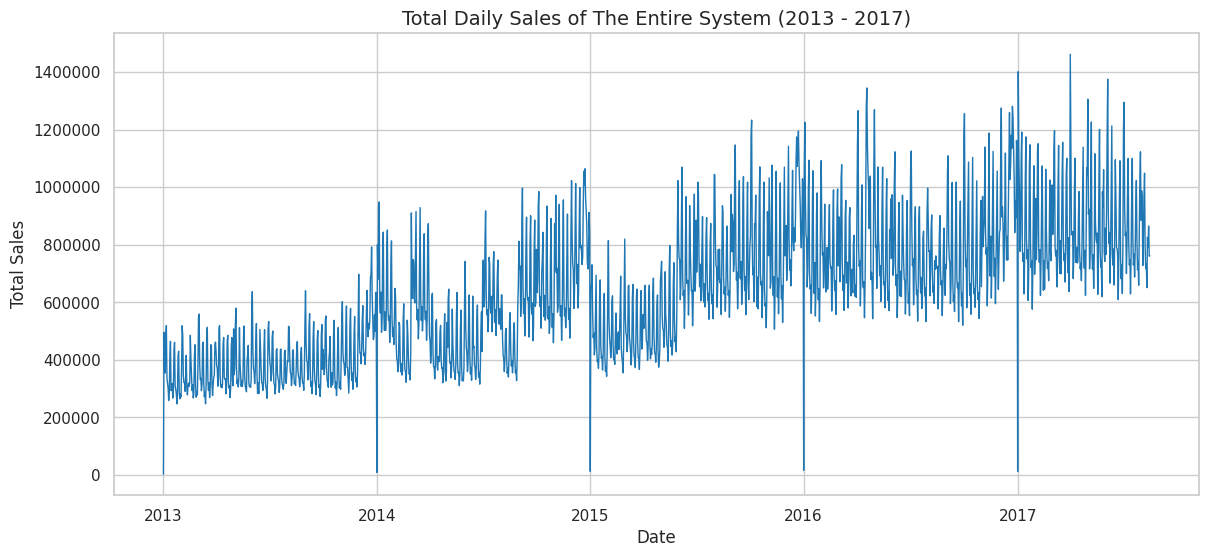

In [36]:

plt.figure(figsize=(14, 6))

daily_sales = df.groupby('date')['sales'].sum().reset_index()
plt.plot(daily_sales['date'], daily_sales['sales'], color='tab:blue', linewidth=1)

plt.ticklabel_format(style='plain', axis='y')

plt.title('Total Daily Sales of The Entire System (2013 - 2017)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Sales')

plt.show()

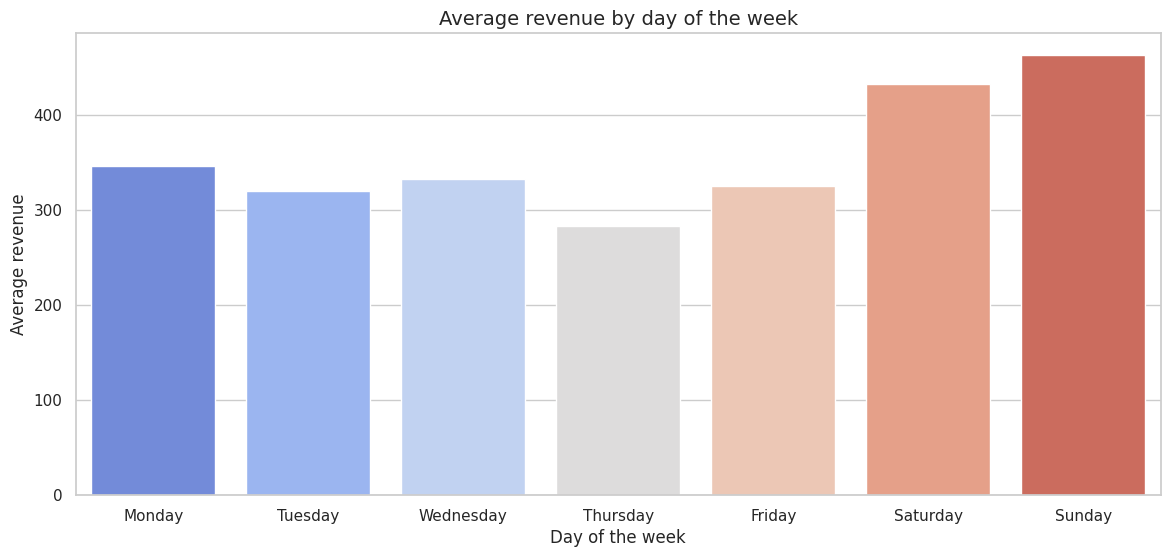

In [37]:
plt.figure(figsize=(14, 6))
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_weekday_sales = df.groupby('day_of_week')['sales'].mean().reindex(days_order).reset_index()
sns.barplot(data=avg_weekday_sales, x='day_of_week', y='sales', palette='coolwarm')
plt.title('Average revenue by day of the week', fontsize=14)
plt.xlabel('Day of the week')
plt.ylabel('Average revenue')
plt.show()

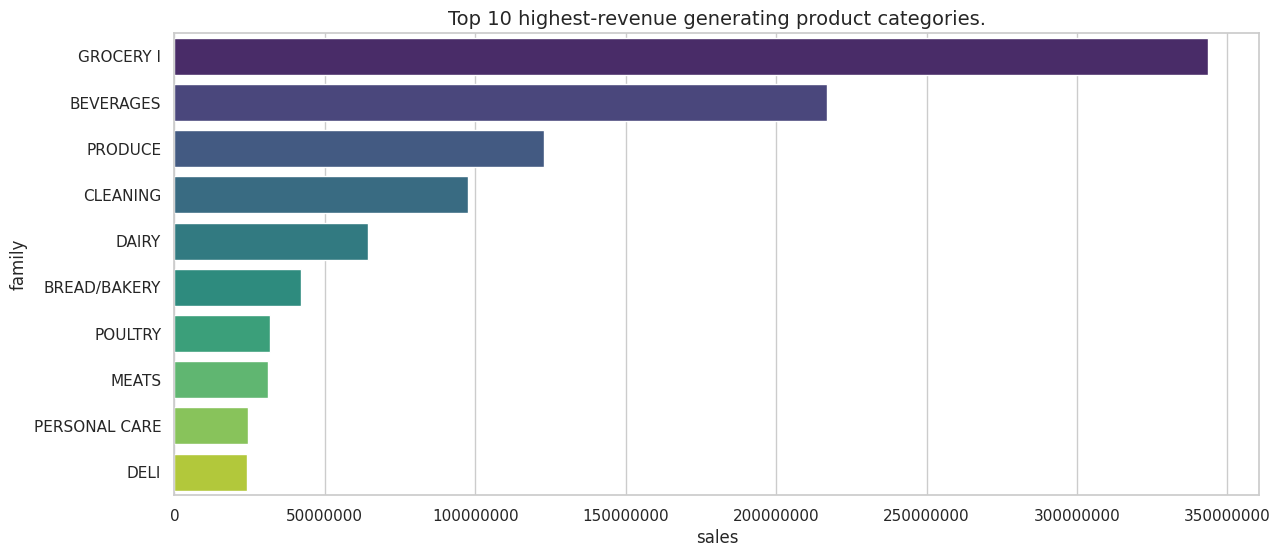

In [38]:
plt.figure(figsize=(14, 6))

top_family = df.groupby('family')['sales'].sum().sort_values(ascending=False).head(10).reset_index()
sns.barplot(data=top_family, x='sales', y='family', palette='viridis')

plt.ticklabel_format(style='plain', axis='x')

plt.title('Top 10 highest-revenue generating product categories.', fontsize=14)
plt.show()

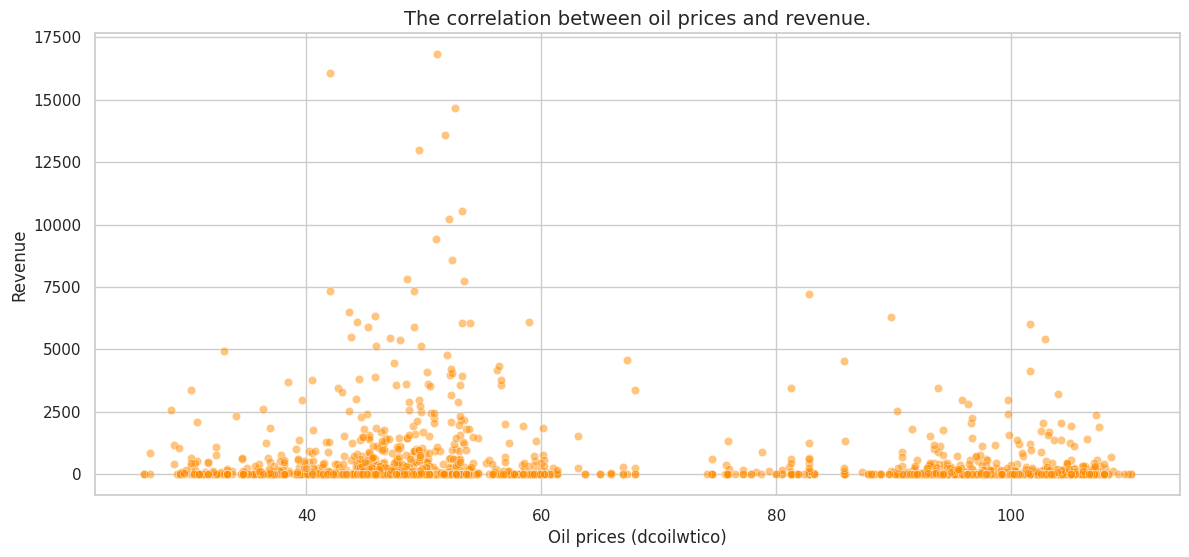

In [39]:
plt.figure(figsize=(14, 6))
# Kiểm tra nếu có cột dcoilwtico (giá dầu) thì mới vẽ
if 'dcoilwtico' in df.columns:
    df_sample = df.sample(2000, random_state=42)
    sns.scatterplot(data=df_sample, x='dcoilwtico', y='sales', alpha=0.5, color='darkorange')
    plt.title('The correlation between oil prices and revenue.', fontsize=14)
    plt.xlabel('Oil prices (dcoilwtico)')
    plt.ylabel('Revenue')
else:
    print("Warning: No dcoilwtico oil price column found to draw the Scatter Plot!")
plt.show()